# Comparação do Impacto do Balanceamento de Classes

Avalia o impacto da aplicação de pesos de classe (_class weight_) para compensar o desbalanceamento entre as classes do dataset.

**Configuração base (herdada do notebook anterior):**
- Normalização: `preprocess_input`
- Data augmentation: ativado
- Learning rate: `0.001`
- Threshold de decisão: `0.5`

**Variável analisada:** uso de pesos inversamente proporcionais à frequência de cada classe

| Experimento | Balanceamento |
|---|---|
| `*-baseline` | desativado |
| `*-class-weight` | ativado — pesos calculados pelo método `balanced` do scikit-learn |

O dataset de Kermany et al. (2018) apresenta desbalanceamento entre as classes: 1.341 imagens normais contra 3.875 com pneumonia no conjunto de treino (proporção aproximada de 1:3). O balanceamento por pesos penaliza erros na classe minoritária durante o treinamento, buscando reduzir o viés do modelo em direção à classe majoritária.

## Preparação do ambiente e carregamento dos experimentos

Clonagem do repositório do GitHub

In [12]:
%cd /content
!git clone https://github.com/amartinsmg/classification-of-medical-images-using-cnn.git
%cd /content/classification-of-medical-images-using-cnn

/content
fatal: destination path 'classification-of-medical-images-using-cnn' already exists and is not an empty directory.
/content/classification-of-medical-images-using-cnn


Montagem do Google Drive

In [13]:
from google.colab import drive

drive.mount("/content/drive")

BASE_PATH = "/content/drive/MyDrive/classification-of-medical-images-using-cnn/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Definição dos:
- Nomes dos experimentos analisados
- Caminho relativo do diretório onde as comparações serão salvas
- Caminho da pasta onde os resultados dos modelos estão salvos no Google Drive
- Caminho da pasta onde as comparações serão no Google Drive

In [14]:
experiment_names = ["resnet-no-data-aug", "resnet-class-weight",
                  "densenet-no-data-aug", "densenet-class-weight",
                  "efficientnet-no-data-aug", "efficientnet-class-weight"]
COMPARISON_PATH = "comparisons/03-class-weight"
RESULT_PATH = BASE_PATH + "results"
SAVE_DIR = BASE_PATH + COMPARISON_PATH

Carregamento dos experimentos

In [15]:
from src.analyses import load_experiments

experiments = load_experiments(RESULT_PATH, experiment_names)


## Visualização das métricas finais com média e desvio padrão

In [16]:
from src.analyses import metrics_table
from IPython.display import display

metrics = metrics_table(experiments)
display(metrics)

,accuracy-mean,accuracy-std,precision-mean,precision-std,recall-mean,recall-std,f1-score-mean,f1-score-std,specificity-mean,specificity-std,auc-roc-mean,auc-roc-std
experiment,,,,,,,,,,,,
resnet-no-data-aug,0.808226,0.018704,0.768948,0.019748,0.992308,0.004187,0.866276,0.010908,0.501425,0.056730,0.963535,0.003811
resnet-class-weight,0.831197,0.053908,0.818086,0.086537,0.961538,0.042028,0.879198,0.030881,0.613960,0.211681,0.960545,0.005001
densenet-no-data-aug,0.819979,0.056270,0.788886,0.064417,0.985470,0.015432,0.874262,0.033387,0.544160,0.174756,0.962950,0.003478
densenet-class-weight,0.844017,0.042042,0.823509,0.069227,0.969231,0.032636,0.887430,0.024917,0.635328,0.165745,0.960771,0.003623
efficientnet-no-data-aug,0.796474,0.030095,0.756865,0.028928,0.996581,0.003198,0.859976,0.017490,0.462963,0.085494,0.968920,0.002772
efficientnet-class-weight,0.845085,0.004206,0.806926,0.006896,0.988889,0.004835,0.888649,0.002221,0.605413,0.019218,0.969958,0.001839


## Visualização dos gráficos dos experimentos com ResNet

- Visualização dos gráficos de treino/validação
- Visualização das curvas ROC dos experimentos

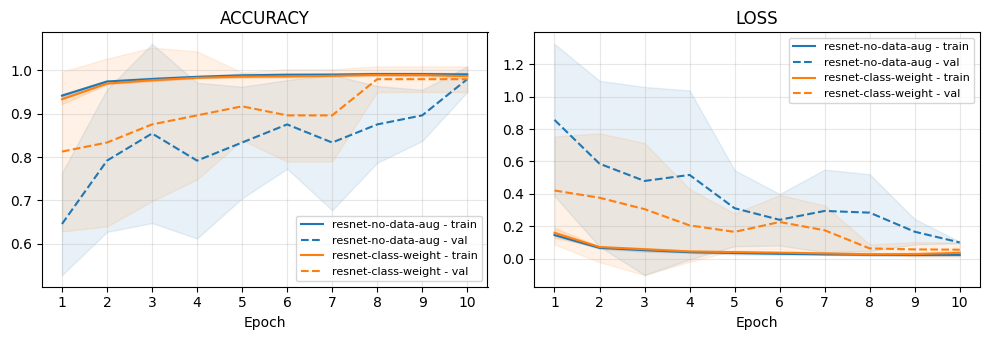

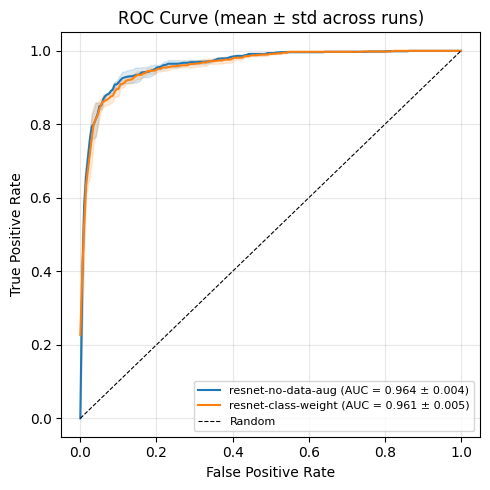

In [17]:
from src.analyses import plot_training_history
from src.analyses import plot_roc_curves
import matplotlib.pyplot as plt

resnet_exps = [exp for exp in experiments if exp.get("name").startswith("resnet")]

fig_history = plot_training_history(resnet_exps, metrics=["accuracy", "loss"])
fig_roc = plot_roc_curves(resnet_exps)

plt.show()

## Visualizaçãs dos gráficos dos experimentos com DenseNet

- Visualização dos gráficos de treino/validação
- Visualização das curvas ROC dos experimentos

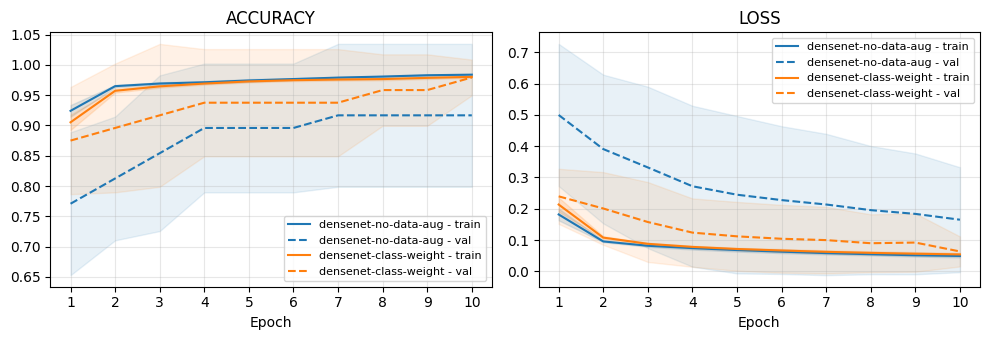

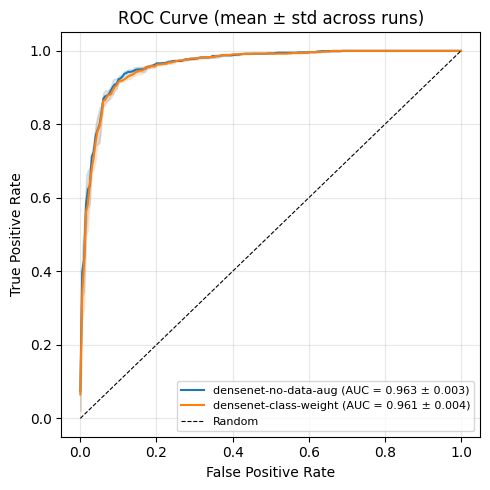

In [18]:
densenet_exps = [exp for exp in experiments if exp.get("name").startswith("densenet")]

fig = plot_training_history(densenet_exps, metrics=["accuracy", "loss"])
fig = plot_roc_curves(densenet_exps)

plt.show()

## Visualizaçãs dos gráficos dos experimentos com EfficientNet

- Visualização dos gráficos de treino/validação
- Visualização das curvas ROC dos experimentos

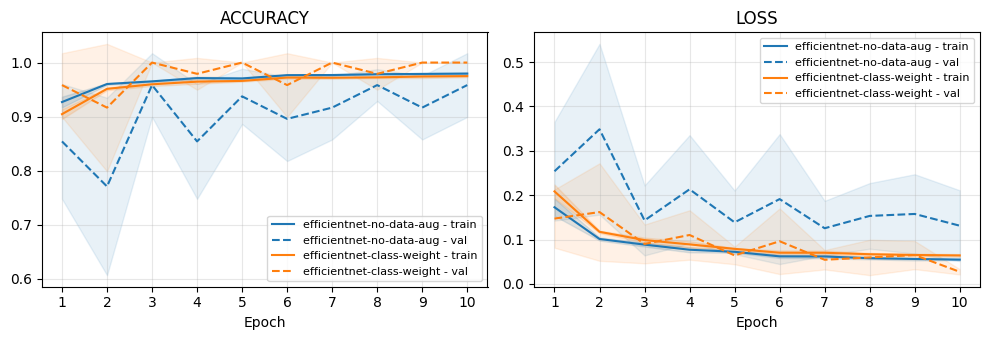

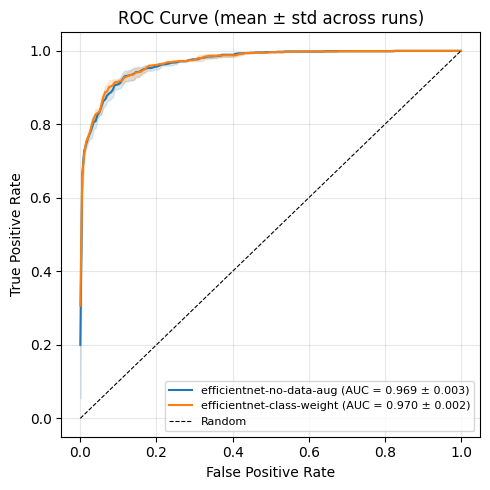

In [19]:
efficientnet_exps = [exp for exp in experiments if exp.get("name").startswith("efficientnet")]

fig = plot_training_history(efficientnet_exps, metrics=["accuracy", "loss"])
fig = plot_roc_curves(efficientnet_exps)

plt.show()

## Salvamento da comparação completa

A comparação completa é salva no Google Drive

In [20]:
from src.analyses import full_comparison

_ = full_comparison(
  base_result_dir=RESULT_PATH,
  experiment_names=experiment_names,
  history_metrics=["accuracy", "loss"],
  show_plot=False,
  save_dir=SAVE_DIR,
  separe_archs=True
)


Results saved in /content/drive/MyDrive/classification-of-medical-images-using-cnn/comparisons/03-class-weight


Upload da tabela e dos gráficos para o DagsHub

In [ ]:
%pip install -q dvc dagshub

import dagshub
from google.colab import userdata

dagshub.auth.add_app_token(token=userdata.get("DAGSHUB_TOKEN"))

DAGSHUB_REPO = "amartinsmg/classification-of-medical-images-using-cnn"

dagshub.upload_files(
    DAGSHUB_REPO,
    local_path=SAVE_DIR,
    remote_path=COMPARISON_PATH,
    force=True
)